In [1]:
import pandas as pd 
import numpy as np

data = pd.read_excel("D:/ML RESUME PROJECTS/Customer Segmentation/data/Online Retail.xlsx",sheet_name=0)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_insta

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Om\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_insta

AttributeError: _ARRAY_API not found

In [2]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
data.shape

(541909, 8)

In [4]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
data.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [6]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### now from this much data exploration, we can see that there are negative unit prices which are not logical, customer ids which are nulls and also we have negative quantity but that signifies a return i.e the product was returned. 

### there is something interesting that there are multiple sam einvoice numbers on each row which signifies that each row shows the product details and not the customer details. so we nee dto handle thatas well

In [7]:
# handling missing values (customer id)

data.dropna(subset=["CustomerID"], inplace=True)

In [8]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
data.shape

(406829, 8)

In [10]:
unit_pri_neg = data[data["UnitPrice"] < 0]
unit_pri_neg.shape

(0, 8)

In [11]:
print("Negative UnitPrice rows:", data[data['UnitPrice'] < 0].shape[0])
print("Negative Quantity rows:", data[data['Quantity'] < 0].shape[0])
print("Null CustomerIDs:", data['CustomerID'].isnull().sum())
print("Remaining shape:", data.shape)

Negative UnitPrice rows: 0
Negative Quantity rows: 8905
Null CustomerIDs: 0
Remaining shape: (406829, 8)


In [14]:
# making the total spend column 
data["TotalSpend"] = data["Quantity"] * data["UnitPrice"]
data[["Quantity","UnitPrice","TotalSpend"]].head(10)

,Quantity,UnitPrice,TotalSpend
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [13]:
data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


### let us compute the RFM (recency, frequency and monetary) aggregations for customer segmentation

In [20]:
reference_date = data["InvoiceDate"].max()

rfm = data.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", "max"),
    Frequency = ("InvoiceNo","nunique"),
    Monetary = ("TotalSpend","sum")
)

rfm["Recency"] = (reference_date - rfm["Recency"]).dt.days

In [21]:
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40
12352.0,35,11,1545.41
12353.0,203,1,89.00
12354.0,231,1,1079.40
12355.0,213,1,459.40


In [22]:
rfm.shape

(4372, 3)

In [23]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,91.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,0.000000,1.000000,-4287.630000
25%,16.000000,1.000000,293.362500
50%,49.000000,3.000000,648.075000
75%,142.000000,5.000000,1611.725000
max,373.000000,248.000000,279489.020000


### we can see there are negative monetary values which may distortthe entire clustering process as centroids will shift in the wrong direction. so we need to drop the rows with monetary < 0

In [26]:
rfm = rfm[rfm["Monetary"] > 0]

In [27]:
rfm.shape

(4322, 3)

In [30]:
pd.set_option('display.float_format', '{:.2f}'.format)
rfm.describe()

,Recency,Frequency,Monetary
count,4322.00,4322.00,4322.00
mean,89.34,5.12,1923.48
std,99.13,9.38,8263.13
min,0.00,1.00,0.00
25%,16.00,1.00,302.29
50%,48.50,3.00,657.55
75%,137.00,6.00,1625.74
max,373.00,248.00,279489.02


### Scaling the values or standardizing them before segmentation

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [32]:
rfm_scaled.shape

(4322, 3)

In [33]:
print(rfm_scaled.mean(axis=0).round(2)) 
print(rfm_scaled.std(axis=0).round(2)) 

[-0.  0.  0.]
[1. 1. 1.]


### Applying PCA

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 2 )
rfm_pca = pca.fit_transform(rfm_scaled)

print(rfm_pca.shape)
print("Variance explained: ",pca.explained_variance_ratio_)

(4322, 2)
Variance explained:  [0.55944298 0.30107891]


### variance retained is above 80 percent which is acceptable

# CLUSTERING

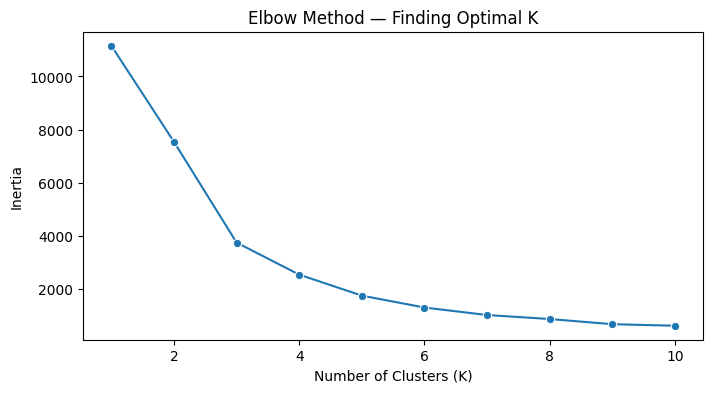

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_pca)  # what goes here?
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 4))
sns.lineplot(x=list(K_range), y=inertias, marker='o')
plt.title('Elbow Method — Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

### we can see that the elbow is between 2 and 4 i.e immediate change in the drop of inertia can be seen here. so we can try with k = 3 and k = 4 as optimum values of k

In [42]:
kmeans = KMeans(n_clusters=3,init="k-means++", random_state=42)
kmeans.fit(rfm_pca)
rfm["Cluster"] = kmeans.labels_

In [43]:
print(rfm['Cluster'].value_counts())

Cluster
1    3220
0    1088
2      14
Name: count, dtype: int64


In [44]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,241.46,1.86,487.71
1,38.31,5.78,1953.38
2,6.14,105.21,106628.21


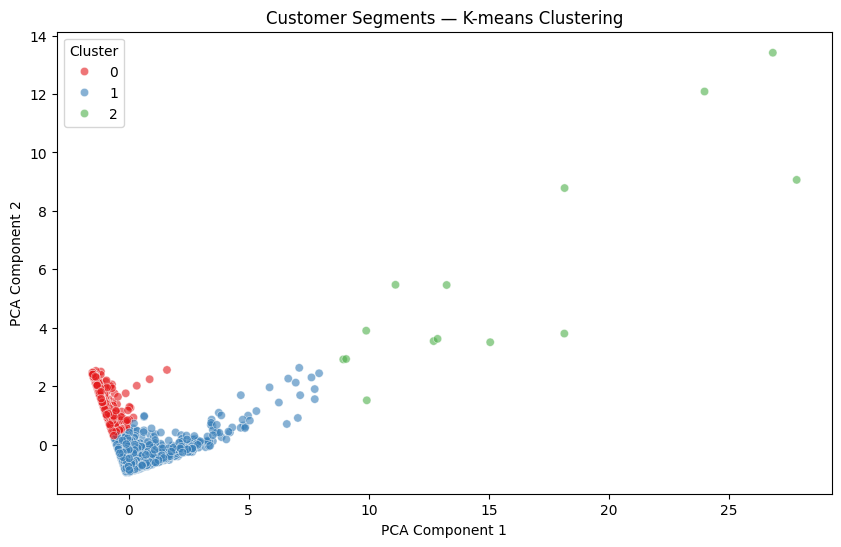

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=rfm_pca[:, 0], 
    y=rfm_pca[:, 1],
    hue=rfm['Cluster'],
    palette='Set1',
    alpha=0.6
)
plt.title('Customer Segments — K-means Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

### Using DBSCAN

In [46]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_pca)

print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4292
-1      30
Name: count, dtype: int64


In [47]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_pca)
print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4311
-1      11
Name: count, dtype: int64


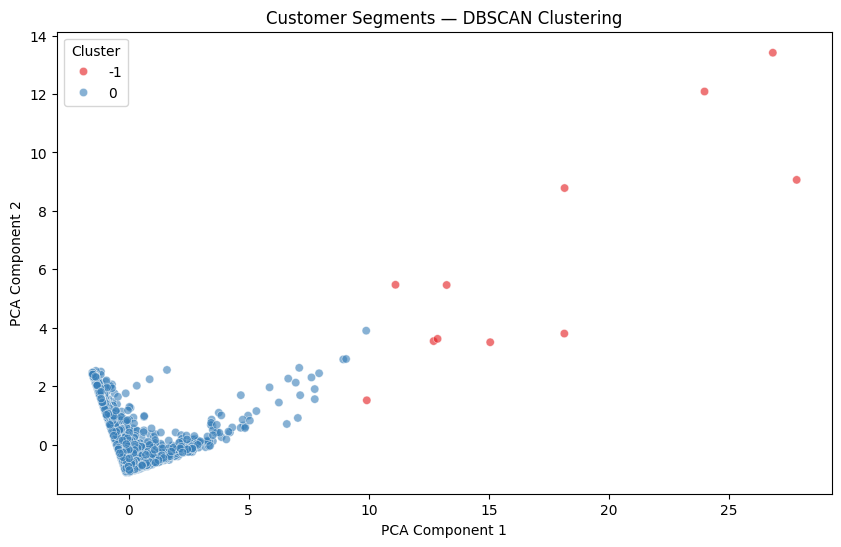

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=rfm_pca[:, 0],
    y=rfm_pca[:, 1],
    hue=rfm['DBSCAN_Cluster'],
    palette='Set1',
    alpha=0.6
)
plt.title('Customer Segments — DBSCAN Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

C:\Users\Om\AppData\Local\Temp\ipykernel_14812\6715446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Om\AppData\Local\Temp\ipykernel_14812\6715446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Om\AppData\Local\Temp\ipykernel_14812\6715446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


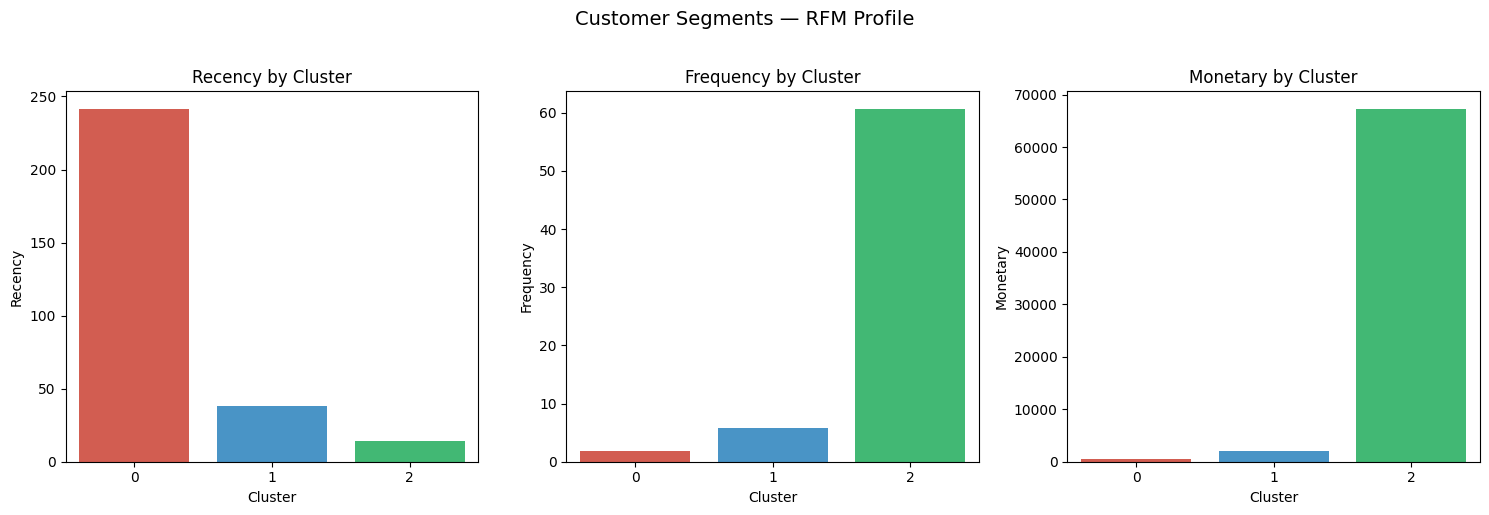

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Recency', 'Frequency', 'Monetary']
colors  = ['#e74c3c', '#3498db', '#2ecc71']

for i, metric in enumerate(metrics):
    rfm_kmeans = rfm[rfm['DBSCAN_Cluster'] != -1]
    sns.barplot(
        data=rfm_kmeans,
        x='Cluster',
        y=metric,
        palette=colors,
        ax=axes[i],
        errorbar=None
    )
    axes[i].set_title(f'{metric} by Cluster')
    axes[i].set_xlabel('Cluster')

plt.suptitle('Customer Segments — RFM Profile', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()